#5B Taller aplicado ANN Predicción de la eficiencia de la gasolina

In [1]:
!pip install ucimlrepo

Realizar un modelo de regresion con redes neuronales densas para predeccir la eficiencia de los vehiculos utilizando un dataset llamado Auto MPG

## Importar librerias

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import pathlib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [3]:
!python -V

Python 3.11.12


In [4]:
print(tf.__version__)

2.18.0


# Importar datos

Este código descarga el dataset Auto MPG, lo carga en Pandas DataFrame y muestra su estructura. Este dataset se usa comúnmente en problemas de regresión para predecir el consumo de combustible de un automóvil en función de características como peso, potencia y cilindros.

In [5]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# metadata
print(auto_mpg.metadata)

# variable information
print(auto_mpg.variables)


{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

In [6]:
type(X)

pandas.core.frame.DataFrame

In [7]:
X

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1
...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1
394,97.0,4,52.0,2130,24.6,82,2
395,135.0,4,84.0,2295,11.6,82,1
396,120.0,4,79.0,2625,18.6,82,1


In [8]:
type(y)

pandas.core.frame.DataFrame

In [9]:
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
393,27.0
394,44.0
395,32.0
396,28.0


# EDA

In [10]:
print(X.isnull().sum())
print(y.isnull().sum())

displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64
mpg    0
dtype: int64


In [11]:
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
393,27.0
394,44.0
395,32.0
396,28.0


Limpiemos los nulos, la condicion es que cualquier nulo quitamos la fila no la columna

In [12]:
df=X.join(y)
df

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1,27.0
394,97.0,4,52.0,2130,24.6,82,2,44.0
395,135.0,4,84.0,2295,11.6,82,1,32.0
396,120.0,4,79.0,2625,18.6,82,1,28.0


In [13]:
print(df.isnull().sum())

displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64


In [14]:
df.shape

(398, 8)

In [15]:
df=df.dropna(axis=0)  #df.dropna(axis=0, inlpace=True)
df.shape

(392, 8)

In [16]:
df

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1,27.0
394,97.0,4,52.0,2130,24.6,82,2,44.0
395,135.0,4,84.0,2295,11.6,82,1,32.0
396,120.0,4,79.0,2625,18.6,82,1,28.0


In [17]:
# reindexar el dataframe

In [18]:
df=df.reset_index(drop=True)
df


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...
387,140.0,4,86.0,2790,15.6,82,1,27.0
388,97.0,4,52.0,2130,24.6,82,2,44.0
389,135.0,4,84.0,2295,11.6,82,1,32.0
390,120.0,4,79.0,2625,18.6,82,1,28.0


Vamos a graficar la correlaciones utilizador pairplot de seaborn

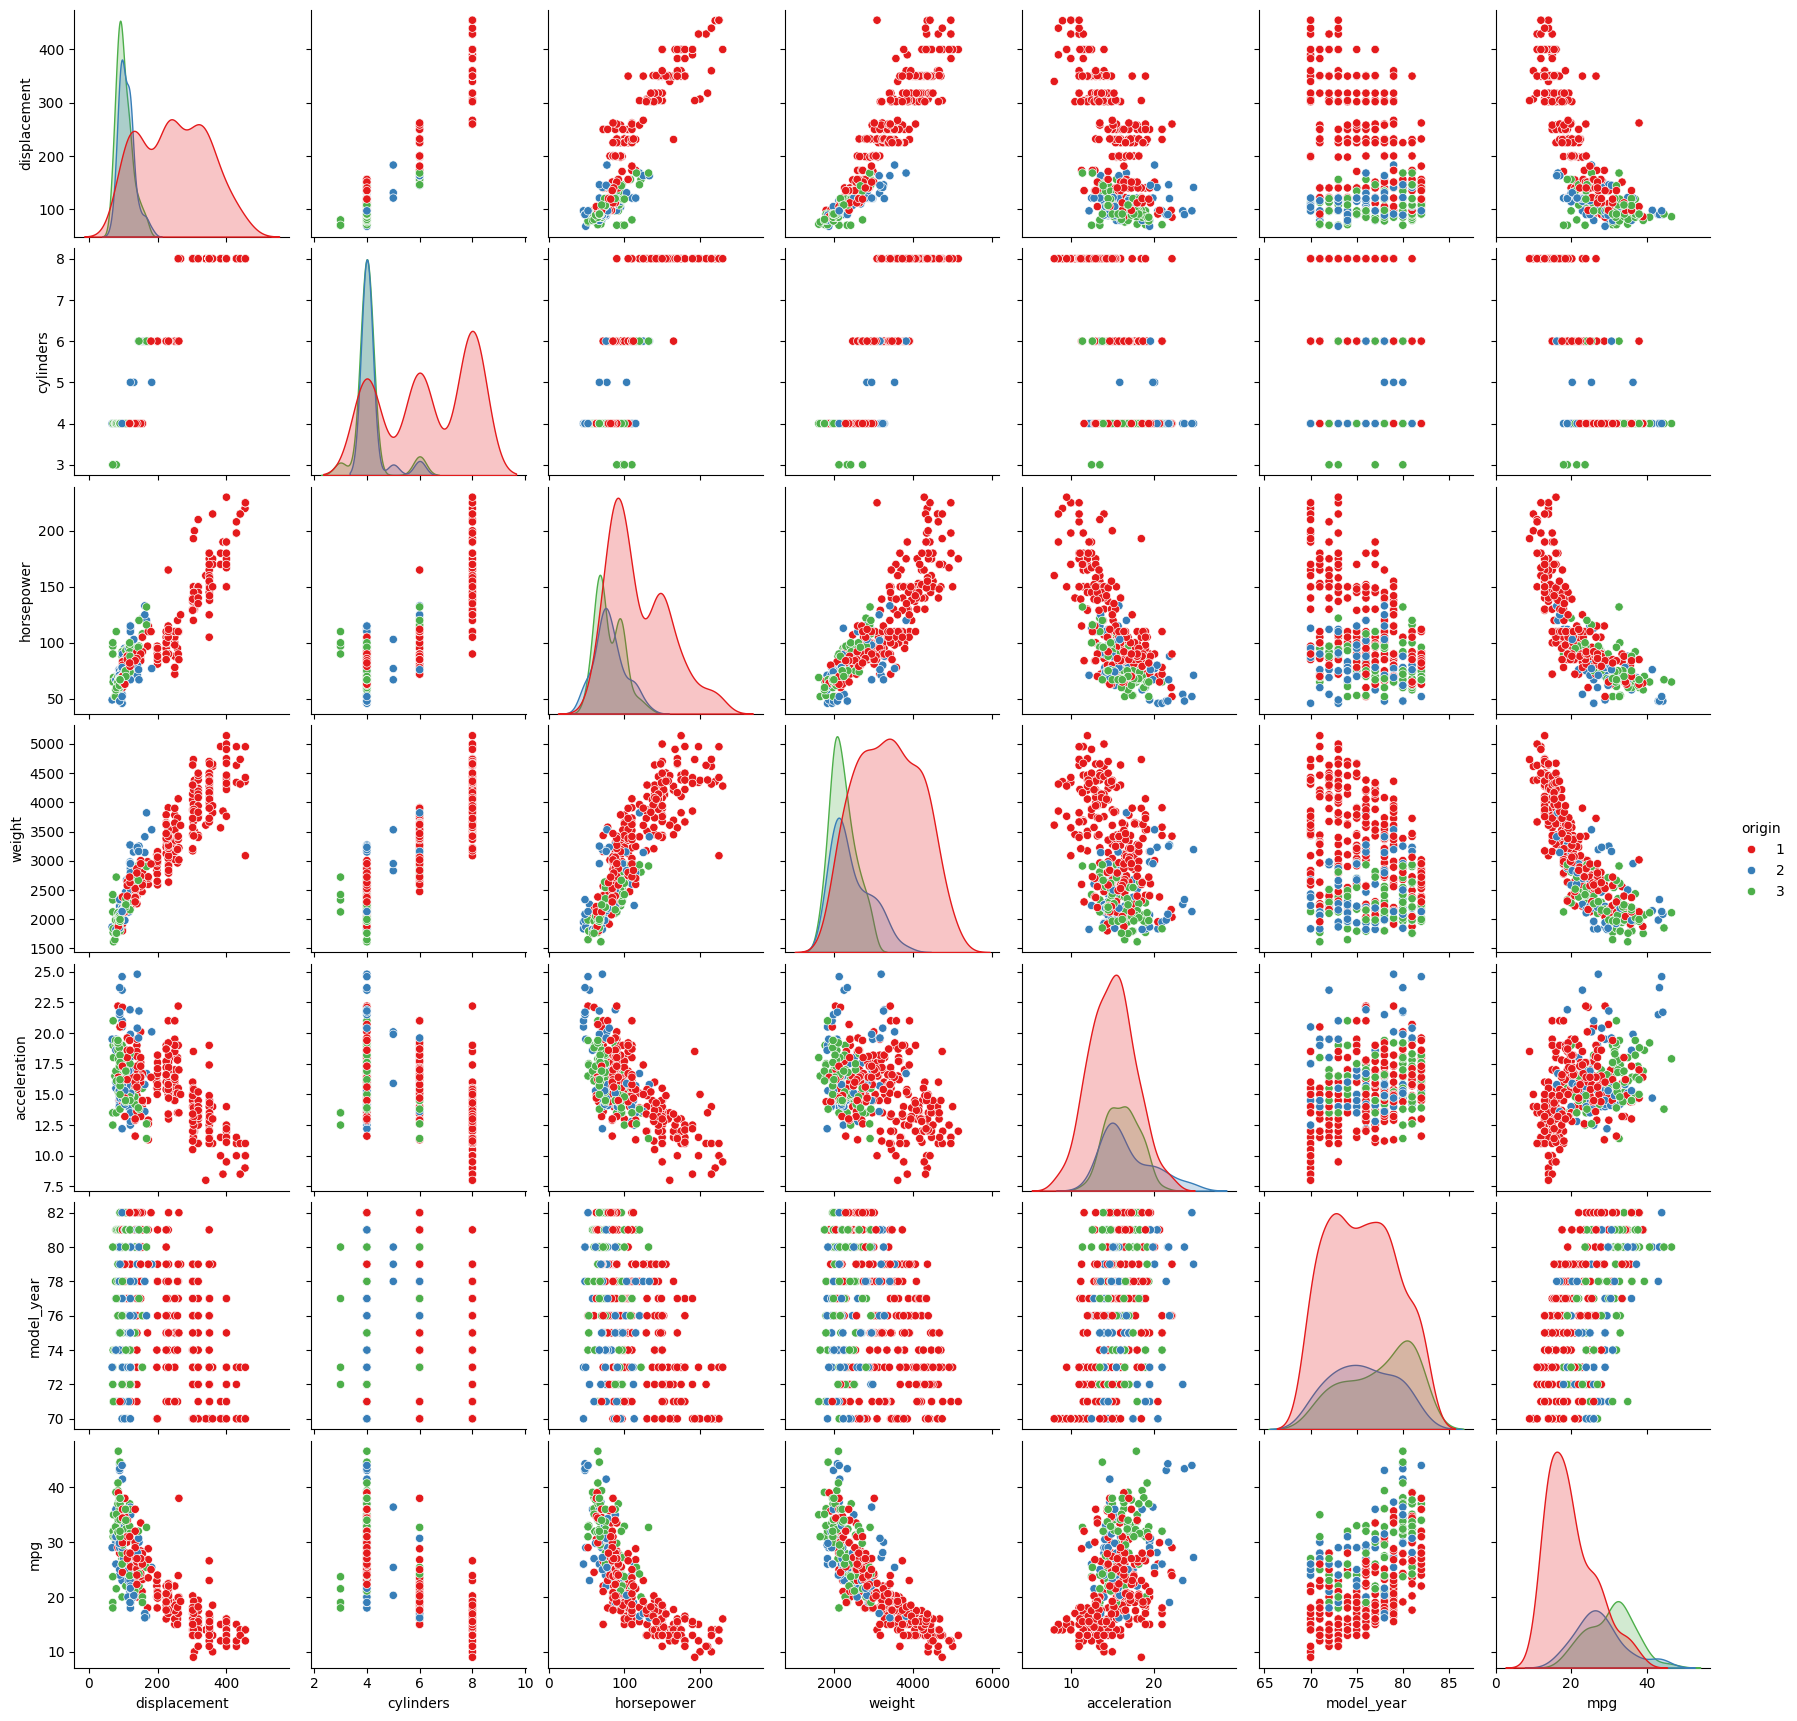

In [19]:
sns.pairplot(df,diag_kind='kde',hue='origin', palette='Set1')

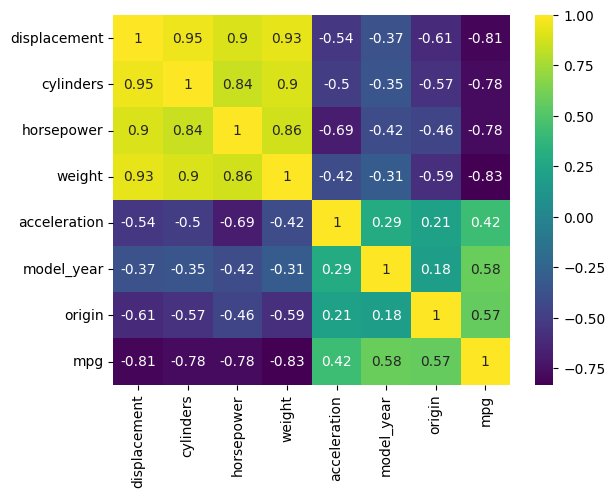

In [20]:
heatmap=sns.heatmap(df.corr(),annot=True,cmap='viridis')

In [21]:
df.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,194.411990,5.471939,104.469388,2977.584184,15.541327,75.979592,1.576531,23.445918
std,104.644004,1.705783,38.491160,849.402560,2.758864,3.683737,0.805518,7.805007
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,9.000000
25%,105.000000,4.000000,75.000000,2225.250000,13.775000,73.000000,1.000000,17.000000
50%,151.000000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,22.750000
75%,275.750000,8.000000,126.000000,3614.750000,17.025000,79.000000,2.000000,29.000000
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,46.600000


In [22]:
df.columns

Index(['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration',
       'model_year', 'origin', 'mpg'],
      dtype='object')

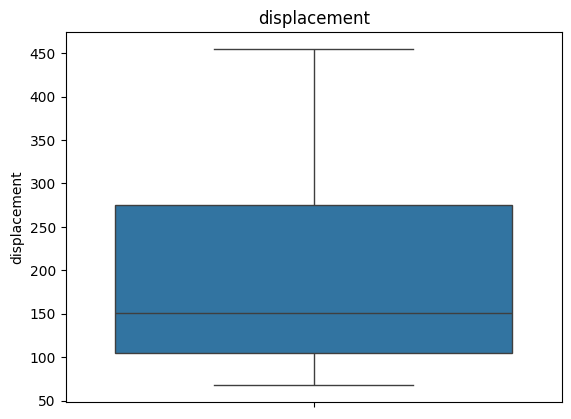

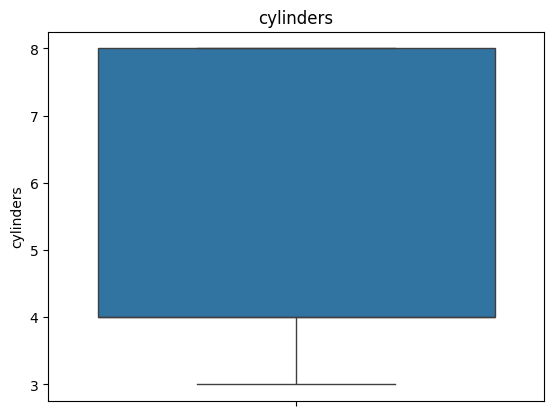

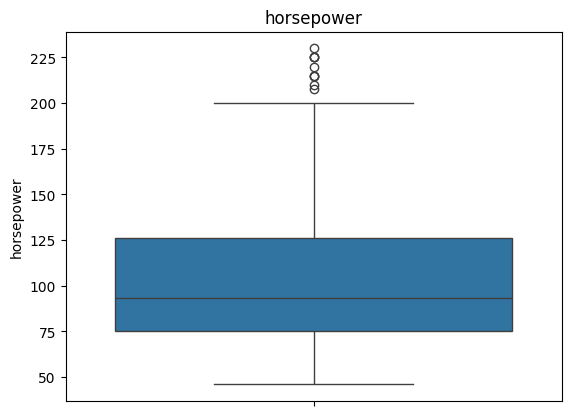

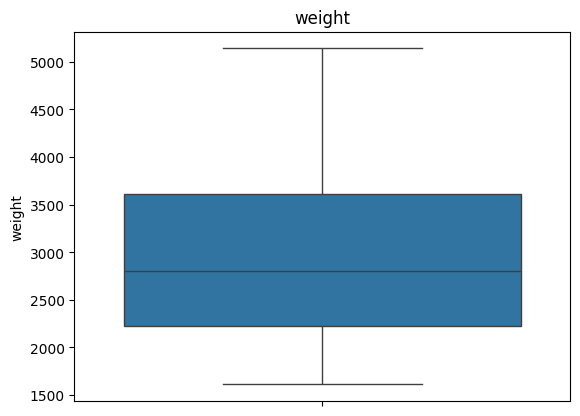

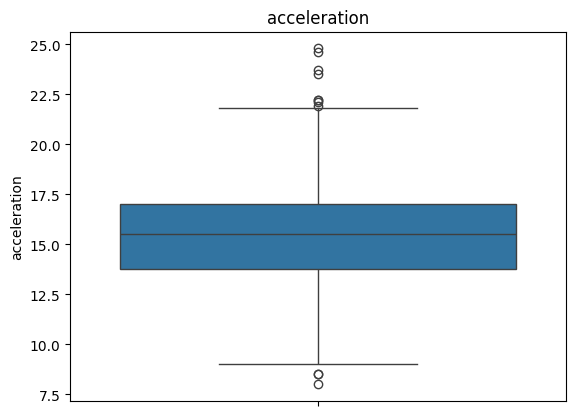

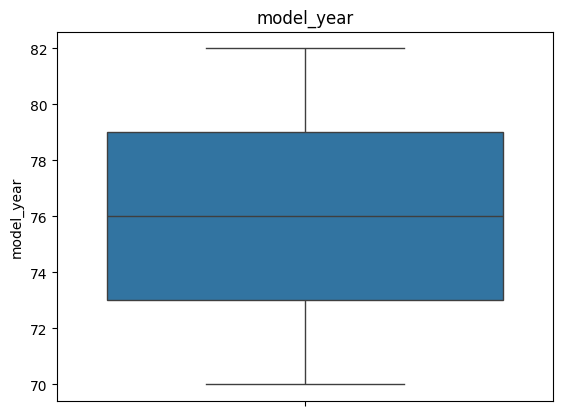

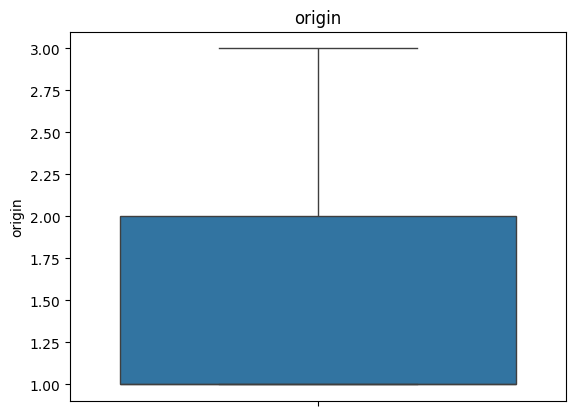

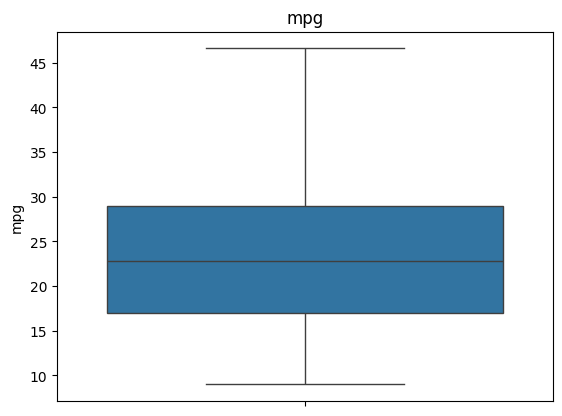

In [23]:
for columns in df.columns:
  sns.boxplot(df[columns])
  plt.title(columns)
  plt.show()

Para calcular el Bogite Superior e inferior use:
$$IQR=Q3-Q1$$

$$BS=Q3+1.5*IQR$$
$$BI=Q1-1.5IQR$$

En horsepower
$$IQR=cuartil(.75)-cuartil(.25)=126-75=51$$
$$BS=cuartil(.75)+1.5(51)=126+1.5(51)$$
$$BI=cuatril(.25)-1.5(51)=75-1.5(51)$$


In [24]:
IQR=df['horsepower'].quantile(.75)-df['horsepower'].quantile(.25)
BShp=df['horsepower'].quantile(.75)+1.5*IQR
BIhp=df['horsepower'].quantile(.25)-1.5*IQR
print(IQR,BShp,BIhp)


51.0 202.5 -1.5


Dado que se observan outlier superiiores a 202.5 en horsepowe, procedemos a borrarlos

In [25]:

df = df[df['horsepower'] <= 202.5]


In [26]:
X=df.drop('mpg',axis=1)
y=df['mpg']

In [27]:
np.random.seed(42)

## Feature engineering

Como displacement y cylinders tiene una correlacion muy alta y al mismo tiempo con otros features, procedemos a borrarlo para evitar colinealidad.

In [28]:
X=X.drop('displacement',axis=1)

Procedemos a normalizar dado que estan los features de diferentes escalas.

In [29]:

from sklearn.preprocessing import MinMaxScaler
#scalador=StandardScaler()
scalador=MinMaxScaler()
X_scal=scalador.fit_transform(X)
X_scal

array([[1.        , 0.54545455, 0.5361497 , 0.23809524, 0.        ,
        0.        ],
       [1.        , 0.77272727, 0.58973632, 0.20833333, 0.        ,
        0.        ],
       [1.        , 0.67532468, 0.51686986, 0.17857143, 0.        ,
        0.        ],
       ...,
       [0.2       , 0.24675325, 0.19336547, 0.21428571, 1.        ,
        0.        ],
       [0.2       , 0.21428571, 0.2869294 , 0.63095238, 1.        ,
        0.        ],
       [0.2       , 0.23376623, 0.31386447, 0.67857143, 1.        ,
        0.        ]])

In [30]:
X_train=pd.DataFrame(X_scal,columns=X.columns)
X_train

,cylinders,horsepower,weight,acceleration,model_year,origin
0,1.0,0.545455,0.536150,0.238095,0.0,0.0
1,1.0,0.772727,0.589736,0.208333,0.0,0.0
2,1.0,0.675325,0.516870,0.178571,0.0,0.0
3,1.0,0.675325,0.516019,0.238095,0.0,0.0
4,1.0,0.610390,0.520556,0.148810,0.0,0.0
...,...,...,...,...,...,...
377,0.2,0.259740,0.333711,0.452381,1.0,0.0
378,0.2,0.038961,0.146583,0.988095,1.0,0.5
379,0.2,0.246753,0.193365,0.214286,1.0,0.0
380,0.2,0.214286,0.286929,0.630952,1.0,0.0


In [31]:
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
387,27.0
388,44.0
389,32.0
390,28.0


In [32]:
import joblib as jb
jb.dump(scalador,'scalador.jb')

['scalador.jb']

## Construccion del modelo
Vamos a construir un modelo de red neuronal con capas densas o densamente conectado, utilice el optimizador RMSprop con un learnig rate igual a 0.01, utilice la funcion de perdida MSE y las metricas va a utilizar mae y mse

In [33]:
X_train.shape[1]

6

In [34]:

# Crear el modelo secuencial
model = Sequential()

# Añadir la capa de entrada con la forma de entrada
model.add(Input(shape=(X_train.shape[1],)))  # Correcto: 'Input' con 'shape' y no 'Input_shape'

# Añadir las capas densas
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1,activation='linear'))

In [35]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.005),
              loss='mse',
              metrics=['mae','mse'])

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history=model.fit(X_train,y,epochs=500,batch_size=32,validation_split=0.2)


Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - loss: 497.4163 - mae: 21.2294 - mse: 497.4163 - val_loss: 779.7823 - val_mae: 27.3206 - val_mse: 779.7823
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 296.9970 - mae: 15.5082 - mse: 296.9970 - val_loss: 375.7288 - val_mae: 18.4702 - val_mse: 375.7288
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 119.0051 - mae: 8.6309 - mse: 119.0051 - val_loss: 153.9747 - val_mae: 11.0134 - val_mse: 153.9747
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 60.5934 - mae: 6.5589 - mse: 60.5934 - val_loss: 90.0729 - val_mae: 8.0036 - val_mse: 90.0729
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 49.2473 - mae: 5.8193 - mse: 49.2473 - val_loss: 76.9023 - val_mae: 7.2208 - val_mse: 76.9023
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 33.9583 - mae: 4.6920 - mse: 33.9583 - val_loss: 45.4488 - val_mae: 5.1548 - val_mse: 45.4488
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2

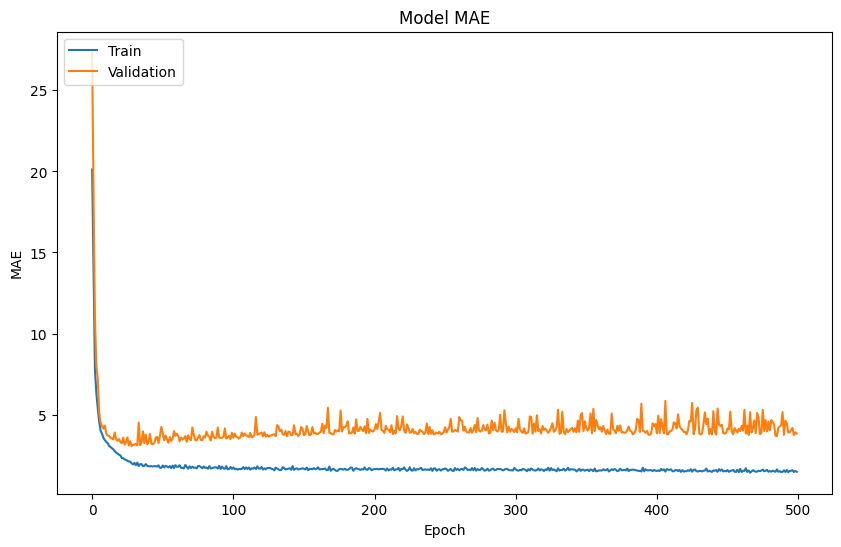

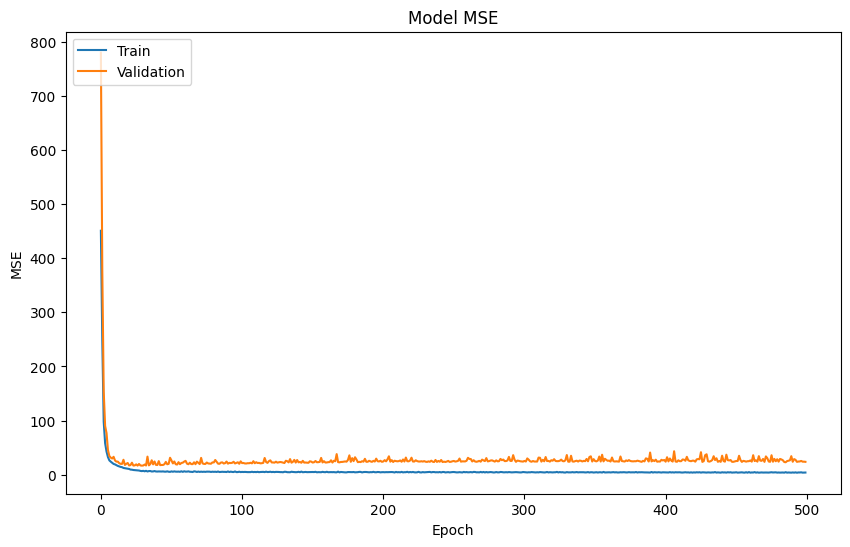

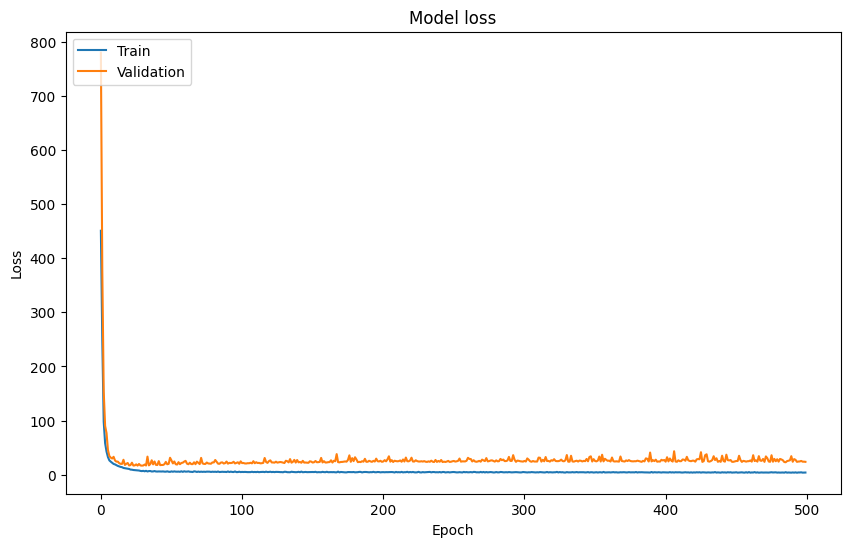

In [38]:
# prompt: quiero graficar de la variable historia el history del mae el mse y las perdidas

import matplotlib.pyplot as plt

# Assuming 'history' is the object returned by model.fit
plt.figure(figsize=(10, 6))

# Plot training & validation MAE values
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.figure(figsize=(10, 6))

# Plot training & validation MSE values
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.title('Model MSE')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.figure(figsize=(10, 6))

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [39]:
keras.models.save_model(model,'model_mpg.keras')

In [40]:
X.describe()

,cylinders,horsepower,weight,acceleration,model_year,origin
count,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000
mean,5.405759,101.476440,2940.947644,15.666754,76.107330,1.591623
std,1.677477,34.163314,825.667561,2.667648,3.638017,0.810517
min,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,4.000000,75.000000,2220.000000,14.000000,73.000000,1.000000
50%,4.000000,92.000000,2764.500000,15.500000,76.000000,1.000000
75%,6.000000,119.000000,3533.750000,17.200000,79.000000,2.000000
max,8.000000,200.000000,5140.000000,24.800000,82.000000,3.000000


Realicemos una prediccón

In [41]:
import pandas as pd
# Cargar el modelo y el escalador
model = keras.models.load_model('model_mpg.keras')
scalador = jb.load('scalador.jb')

# Crear un conjunto de datos de entrada sintético
# Cambiar 'model year' a 'model_year' para que coincida con el nombre de la columna durante el entrenamiento
synthetic_data = pd.DataFrame({
    'cylinders': [4, 6, 8],
    'horsepower': [100, 150, 200],
    'weight': [2500, 3000, 3500],
    'acceleration': [15, 18, 12],
    'model_year': [76, 79, 82],
    'origin': [1, 2, 3]
})

# Escalar los datos sintéticos con el escalador cargado
synthetic_data_scaled = scalador.transform(synthetic_data)

# Hacer la predicción utilizando el modelo cargado
predictions = model.predict(synthetic_data_scaled)

# Mostrar las predicciones
print("Predicciones de MPG para los datos sintéticos:")
for i in range(len(predictions)):
    print(f"Entrada {i + 1}: MPG predicho = {predictions[i][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
Predicciones de MPG para los datos sintéticos:
Entrada 1: MPG predicho = 24.707874298095703
Entrada 2: MPG predicho = 18.55476188659668
Entrada 3: MPG predicho = 9.014816284179688
